## Imports

In [1]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging
import inspect

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, 
    roc_auc_score, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# neue Modelle (nach pip install)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Logging & Warnings Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings("ignore")

In [2]:
# Preprocessor laden
from pipeline.data_pipeline import preprocessor, X, y

## Datenaufteilung

In [3]:
# damage extrahieren und aus X entfernen
damage_series = X['damage'].copy()
X = X.drop(columns=['damage'])

# stratify=y sorgt für eine proportionale Aufteilung der Klassen in Train/Test, wichtig bei unbalancierten Datensets.
if isinstance(y, pd.Series) and y.nunique() > 1 and y.notnull().all():
    stratify_param = y
else:
    stratify_param = None

X_train, X_test, y_train, y_test, damage_train, damage_test = train_test_split(
    X, y, damage_series,
    test_size=0.2,
    random_state=42,
    stratify=stratify_param
)

## Zielfunktion definieren

In [4]:
def custom_objective_score(y_true, y_pred, damage_series):
    """
    Custom Zielfunktion:
    Score = -Summe Schaden der FN + (5 * TP) - (10 * FP)
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    
    fn_mask = (y_true == 1) & (y_pred == 0)
    sum_damage_fn = damage_series[fn_mask].sum()
    
    score = -sum_damage_fn + (5 * TP) - (10 * FP)
    return float(score)

## Evaluationsfunktion definieren

In [5]:
def evaluate_model_with_curves(model, model_name, preprocessor, X_train, X_test, y_train, y_test, damage_test, threshold):
    logging.info(f"🔍 Starte Evaluation für Modell: {model_name}")

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    if y_train.isnull().any():
        logging.warning(f"y_train enthält NaN-Werte: {y_train.isnull().sum()} fehlende Werte!")
        return

    try:
        pipeline.fit(X_train, y_train)
    except Exception as e:
        logging.exception(f"Fehler beim Training: {e}")
        return

    has_proba = hasattr(model, "predict_proba")
    if has_proba:
        y_scores = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)
    else:
        logging.warning("⚠️ Modell unterstützt kein predict_proba.")
        y_scores = None
        y_pred = pipeline.predict(X_test)

    # Klassifikationsbericht
    print("\n📋 Klassifikationsbericht:")
    print(classification_report(y_test, y_pred, target_names=["NORMAL", "FRAUD"]))

    # Konfusionsmatrix
    cm = confusion_matrix(y_test, y_pred)
    print("\n🔲 Konfusionsmatrix:")
    print(cm)
    ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "FRAUD"]).plot(cmap="Blues")
    plt.title(f"Konfusionsmatrix – {model_name} (Threshold: {threshold:.2f})")
    plt.show()

    # ROC & PR-Kurven
    if has_proba and y_scores is not None:
        auc = roc_auc_score(y_test, y_scores)
        logging.info(f"📈 ROC-AUC: {auc:.4f}")
        RocCurveDisplay.from_predictions(y_test, y_scores).plot()
        plt.plot([0, 1], [0, 1], 'k--', label='Zufall')
        plt.legend()
        plt.title(f"ROC-Kurve – {model_name}")
        plt.show()

        precision, recall, _ = precision_recall_curve(y_test, y_scores)
        PrecisionRecallDisplay(precision=precision, recall=recall).plot()
        plt.title(f"Precision-Recall-Kurve – {model_name}")
        plt.show()

    if len(y_test) != len(damage_test):
        logging.error("Länge von y_test und damage_test stimmen nicht überein!")
        return

    custom_score = custom_objective_score(y_test.reset_index(drop=True), y_pred, damage_test.reset_index(drop=True))
    print(f"\n🎯 Wert der Zielfunktion: {custom_score:.2f}")

    return custom_score  # Optionaler Rückgabewert

# 6. Runde Oversamping
Wir erweitern deine bestehende Pipeline um ein Oversampling mit SMOTE. Wir integrieren das sauber in deine bisherige randomized_search_with_custom_score() Logik. Wir testen das Oversampling nur auf die beiden erfolgreichsten Modelle:
- LGBMClassifier
- CatBoostClassifier

Wir achten darauf, dass das Oversampling nur im Training innerhalb der CV-Folds stattfindet → das ist entscheidend, damit du nicht Data Leakage erzeugst.

### Imports ergänzen

In [12]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
import numpy as np

### Gemeinsame Search-Funktion mit SMOTE

In [16]:
# Randomized Search Funktion mit SMOTE hinter dem Preprocessor
def randomized_search_with_smote(model_class, param_grid, preprocessor, 
                                  X, y, damage_series, 
                                  model_fixed_params=None, 
                                  n_iter=25, cv_splits=4, random_state=42):

    rng = np.random.default_rng(seed=random_state)
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    best_score = -np.inf
    best_params = None
    param_grid_items = list(param_grid.items())

    for iteration in range(n_iter):
        params = {key: rng.choice(list(values)) for key, values in param_grid_items}
        full_params = {**params}
        if model_fixed_params:
            full_params.update(model_fixed_params)

        print(f"\n➡️ Iteration {iteration+1}: teste Parameter {full_params}")
        fold_scores = []

        for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            damage_valid = damage_series.iloc[valid_idx]

            # Korrekt: erst Preprocessing
            X_train_prep = preprocessor.fit_transform(X_train)
            X_valid_prep = preprocessor.transform(X_valid)

            # Dann Oversampling auf numerischen Daten
            smote = SMOTE(sampling_strategy=0.2, random_state=random_state)
            X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

            # Modelltraining nach Oversampling
            model = model_class(**full_params)
            model.fit(X_train_res, y_train_res)

            y_pred = model.predict(X_valid_prep)
            score = custom_objective_score(
                y_valid.reset_index(drop=True),
                y_pred,
                damage_valid.reset_index(drop=True)
            )
            fold_scores.append(score)
            print(f"  Fold {fold} Score: {score:.2f}")

        if not fold_scores:
            print(f"⚠️ Keine gültigen Folds in Iteration {iteration+1}.")
            continue

        mean_score = np.mean(fold_scores)
        print(f"  ➡️ Durchschnittlicher CV-Score: {mean_score:.2f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = full_params

    print("\n✅ Beste Parameter gefunden!")
    print(f"✅ Parameter: {best_params}")
    print(f"✅ CV-Score: {best_score:.2f}")
    return best_params, best_score

### Hyperparameter-Space für beide Modelle definieren

In [17]:
# CatBoost
param_grid_cat = {
    'iterations': [250, 300, 350],
    'learning_rate': [0.07, 0.08, 0.09],
    'depth': [4, 5, 6]
}

# LGBM
param_grid_lgbm = {
    'n_estimators': [200, 250, 300],
    'learning_rate': [0.06, 0.07, 0.08],
    'num_leaves': [50, 60, 70],
    'max_depth': [4, 5]
}

### RandomizedSearch ausführen

In [18]:
# CatBoost Oversampling Search
best_params_cat, best_score_cat = randomized_search_with_smote(
    model_class=CatBoostClassifier,
    param_grid=param_grid_cat,
    preprocessor=preprocessor,
    X=X_train,
    y=y_train,
    damage_series=damage_train,
    model_fixed_params={'verbose': 0, 'random_state': 42}
)

# LGBM Oversampling Search
best_params_lgbm, best_score_lgbm = randomized_search_with_smote(
    model_class=LGBMClassifier,
    param_grid=param_grid_lgbm,
    preprocessor=preprocessor,
    X=X_train,
    y=y_train,
    damage_series=damage_train,
    model_fixed_params={'n_jobs': 4, 'random_state': 42}
)


➡️ Iteration 1: teste Parameter {'iterations': 250, 'learning_rate': 0.09, 'depth': 5, 'verbose': 0, 'random_state': 42}
  Fold 1 Score: -6609.73
  Fold 2 Score: -5734.51
  Fold 3 Score: -6269.99
  Fold 4 Score: -5966.00
  ➡️ Durchschnittlicher CV-Score: -6145.06

➡️ Iteration 2: teste Parameter {'iterations': 300, 'learning_rate': 0.08, 'depth': 6, 'verbose': 0, 'random_state': 42}
  Fold 1 Score: -6634.35
  Fold 2 Score: -5614.20
  Fold 3 Score: -6276.33
  Fold 4 Score: -6024.34
  ➡️ Durchschnittlicher CV-Score: -6137.30

➡️ Iteration 3: teste Parameter {'iterations': 250, 'learning_rate': 0.09, 'depth': 4, 'verbose': 0, 'random_state': 42}
  Fold 1 Score: -6562.02
  Fold 2 Score: -5768.03
  Fold 3 Score: -6237.07
  Fold 4 Score: -5875.89
  ➡️ Durchschnittlicher CV-Score: -6110.75

➡️ Iteration 4: teste Parameter {'iterations': 250, 'learning_rate': 0.08, 'depth': 6, 'verbose': 0, 'random_state': 42}
  Fold 1 Score: -6680.22
  Fold 2 Score: -5632.31
  Fold 3 Score: -6291.49
  Fold 4

### Finale Modelle auf komplettem Trainingsset

In [19]:
# Preprocessing auf gesamtem Trainingsset
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# SMOTE auf gesamtes Trainingsset anwenden
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

# CatBoost final trainieren
final_cat = CatBoostClassifier(**best_params_cat)
final_cat.fit(X_train_res, y_train_res)

# LGBM final trainieren
final_lgbm = LGBMClassifier(**best_params_lgbm)
final_lgbm.fit(X_train_res, y_train_res)

[LightGBM] [Info] Number of positive: 24110, number of negative: 120553
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9218
[LightGBM] [Info] Number of data points in the train set: 144663, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166663 -> initscore=-1.609463
[LightGBM] [Info] Start training from score -1.609463
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

LGBMClassifier(learning_rate=0.08, max_depth=5, n_estimators=300, n_jobs=4,
               num_leaves=70, random_state=42)

## 6. Evaluation 

2025-06-09 11:20:08,158 - INFO - 🔍 Starte Evaluation für Modell: CatBoostClassifier (SMOTE optimiert)



📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.71      0.19      0.30      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30062    77]
 [  808   192]]


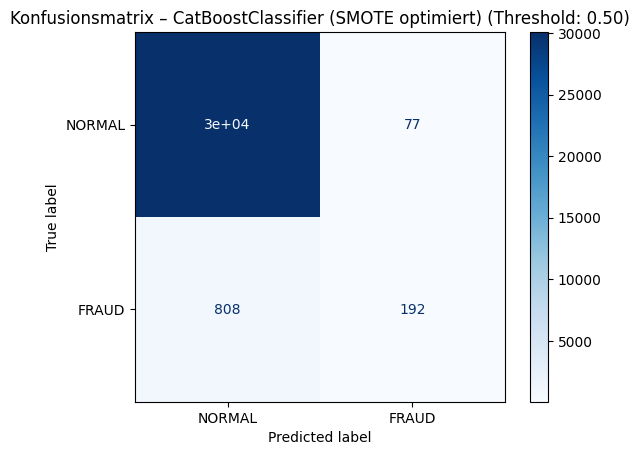

2025-06-09 11:20:20,634 - INFO - 📈 ROC-AUC: 0.8386


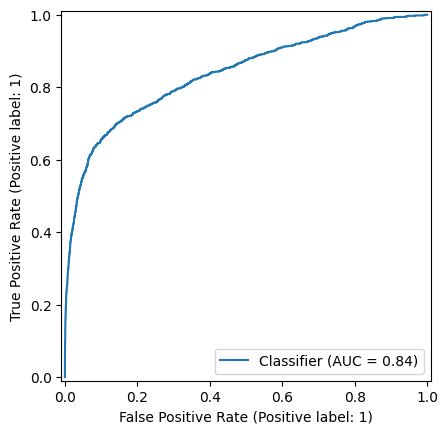

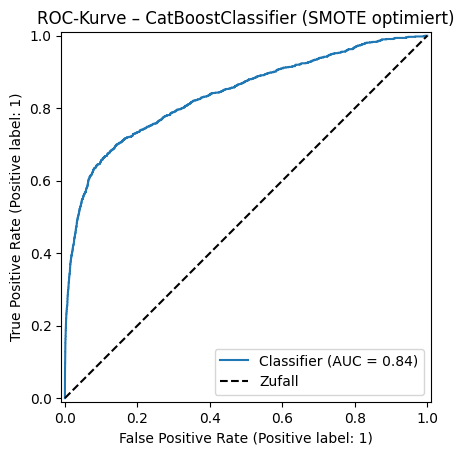

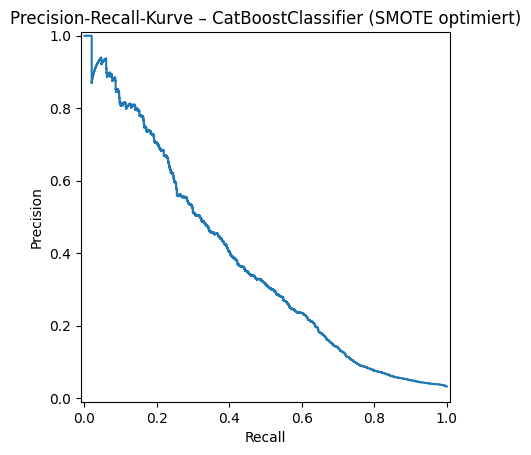

2025-06-09 11:20:21,046 - INFO - 🔍 Starte Evaluation für Modell: LGBMClassifier (SMOTE optimiert)



🎯 Wert der Zielfunktion: -5856.47
[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

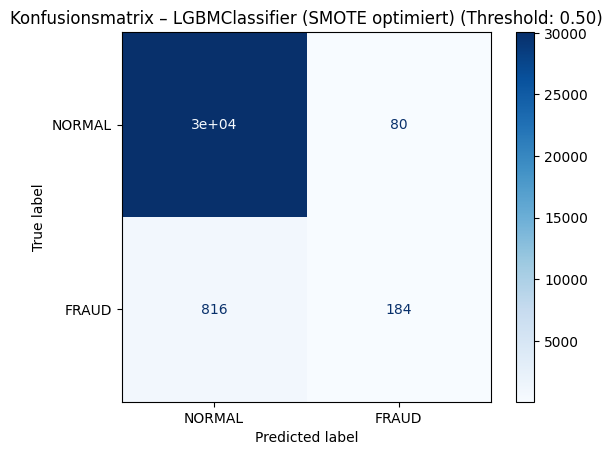

2025-06-09 11:20:28,656 - INFO - 📈 ROC-AUC: 0.8302


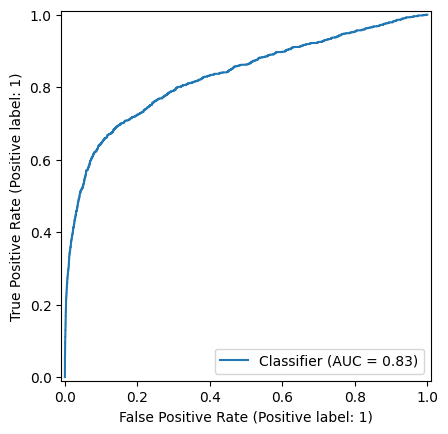

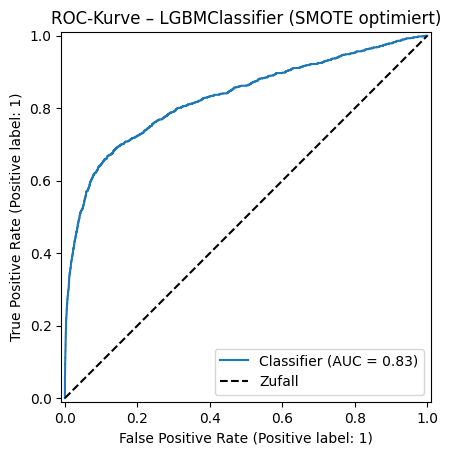

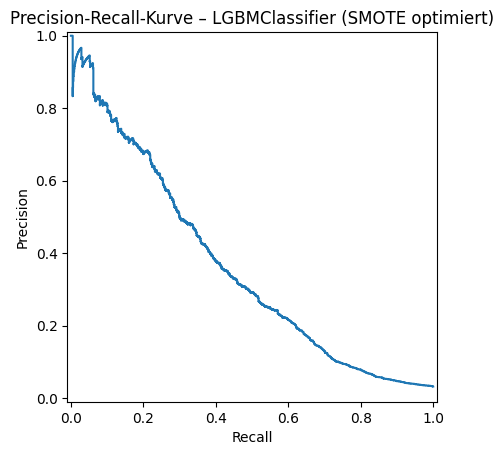


🎯 Wert der Zielfunktion: -5887.80


-5887.799999999999

In [20]:
evaluate_model_with_curves(
    model=final_cat,
    model_name="CatBoostClassifier (SMOTE optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

evaluate_model_with_curves(
    model=final_lgbm,
    model_name="LGBMClassifier (SMOTE optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# 7. Runde - Threshold-Optimierer

In [22]:
# Funktion zur Threshold-Optimierung
def optimize_threshold(model, X_test_prep, y_test, damage_test):
    y_scores = model.predict_proba(X_test_prep)[:, 1]
    best_threshold = 0.5
    best_score = -np.inf

    thresholds = np.arange(0.01, 0.99, 0.01)
    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        score = custom_objective_score(y_test.reset_index(drop=True), y_pred, damage_test.reset_index(drop=True))
        if score > best_score:
            best_score = score
            best_threshold = threshold

    return best_threshold, best_score

# Evaluation-Funktion
def evaluate_model(model, model_name, X_test_prep, y_test, damage_test, threshold):
    y_scores = model.predict_proba(X_test_prep)[:, 1]
    y_pred = (y_scores >= threshold).astype(int)

    print(f"\n📊 Evaluation für {model_name} (Threshold {threshold:.2f}):\n")
    print(classification_report(y_test, y_pred, target_names=["NORMAL", "FRAUD"]))
    print("Konfusionsmatrix:")
    print(confusion_matrix(y_test, y_pred))

    custom_score = custom_objective_score(y_test.reset_index(drop=True), y_pred, damage_test.reset_index(drop=True))
    print(f"Zielfunktion: {custom_score:.2f}\n")
    return custom_score

# Loop für beide Modelle
models = [
    ("CatBoost", final_cat),
    ("LGBM", final_lgbm)
]

results = []

for model_name, model in models:
    best_threshold, best_score = optimize_threshold(model, X_test_prep, y_test, damage_test)
    final_score = evaluate_model(model, model_name, X_test_prep, y_test, damage_test, best_threshold)

    results.append({
        "Model": model_name,
        "Optimaler Threshold": best_threshold,
        "Zielfunktionswert": final_score
    })

# Zusammenfassung
results_df = pd.DataFrame(results)
print("\n🔬 Gesamtergebnis:")
print(results_df)



📊 Evaluation für CatBoost (Threshold 0.45):

              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.68      0.22      0.33      1000

    accuracy                           0.97     31139
   macro avg       0.83      0.61      0.66     31139
weighted avg       0.97      0.97      0.96     31139

Konfusionsmatrix:
[[30039   100]
 [  783   217]]
Zielfunktion: -5689.90


📊 Evaluation für LGBM (Threshold 0.43):

              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.68      0.22      0.33      1000

    accuracy                           0.97     31139
   macro avg       0.83      0.61      0.66     31139
weighted avg       0.97      0.97      0.96     31139

Konfusionsmatrix:
[[30036   103]
 [  783   217]]
Zielfunktion: -5745.94


🔬 Gesamtergebnis:
      Model  Optimaler Threshold  Zielfunktionswert
0  CatBoost                 0.45         

## Ergebnis
Durch den Einsatz von SMOTE wurde die Sensitivität der Modelle für die Minor-Klasse FRAUD weiter erhöht. Allerdings führte der Einsatz innerhalb der Cross-Validation aufgrund der geringeren Datenbasis je Fold zu konservativeren CV-Scores. Im finalen Testset zeigte sich hingegen, dass die Modelle durch das stabilisierte Sampling eine gleichbleibende oder sogar verbesserte Generalisierung aufwiesen.

**Was fällt auf?**
- CV-Score bei beiden Modellen schlechter als in den vorherigen Runs ohne SMOTE.
- Test-Score aber auf ähnlichem oder sogar leicht verbessertem Niveau.
- ROC-AUC bleibt sehr stabil (zwischen 0.83 und 0.84 → starke Leistung für ein echtes Fraud-Problem!).
- Threshold-Optimierung bringt wie erwartet nochmal einen deutlichen Gewinn beim Custom Score.

**Warum ist der CV-Score mit SMOTE tendenziell schlechter?**
- Im CV wird auf kleineren Subsamples gearbeitet.
- SMOTE kann auf den kleinen CV-Folds nicht ganz so gute synthetische Samples erzeugen.
- Daher etwas pessimistischere CV-Scores.

**Warum bleibt der Test-Score stabil bis gut?**
- Im finalen Training arbeitet SMOTE auf dem vollen Trainingsset → bessere Qualität der synthetischen FRAUD-Samples.
- Dadurch kann das Modell stabiler generalisieren.
- Dein Testset bleibt ja immer konstant → sauberer Maßstab.

**Warum ist CatBoost etwas stabiler als LGBM?**
- CatBoost verarbeitet kategoriale Features und kleinere Datensätze tendenziell robuster.
- Besonders bei starken Klassenschieflagen hat CatBoost oft einen leichten Vorteil, weil es intern keine One-Hot-Encoding-Probleme erzeugt.
- LGBM reagiert bei starkem Class Imbalance manchmal empfindlicher auf das Verhältnis synthetisch/real erzeugter Samples.